In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

In [2]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data
y = mnist.target

In [3]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

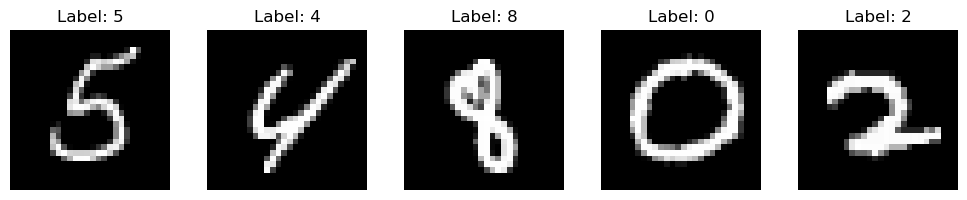

In [5]:
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [6]:
input_dim = 784
latent_dim = 32

In [7]:
input_img = Input(shape=(input_dim,))

# Encoder
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)
latent = Dense(latent_dim, activation='relu')(encoded)

# Decoder
decoded = Dense(64, activation='relu')(latent)
decoded = Dense(128, activation='relu')(decoded)
output_img = Dense(input_dim, activation='sigmoid')(decoded)

In [8]:
autoencoder = Model(input_img, output_img)
encoder = Model(input_img, latent)

In [9]:
autoencoder.compile(optimizer=Adam(), loss='mse')

In [10]:
history = autoencoder.fit(
    X_train, X_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test, X_test)
)

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0660 - val_loss: 0.0390
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0321 - val_loss: 0.0274
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0248 - val_loss: 0.0226
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0213 - val_loss: 0.0203
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0191 - val_loss: 0.0181
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0176 - val_loss: 0.0170
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0166 - val_loss: 0.0161
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0157 - val_loss: 0.0155
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0150 - val_loss: 0.0145
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0142 - val_loss: 0.0139
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0136 - val_loss: 0.0134
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

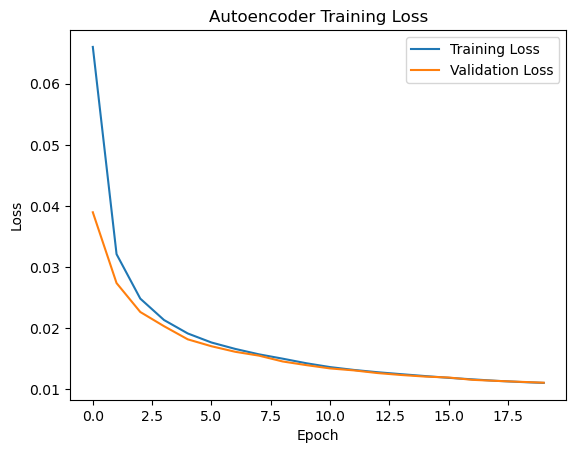

In [11]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Autoencoder Training Loss')
plt.legend()
plt.show()

In [12]:
reconstructed_imgs = autoencoder.predict(X_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


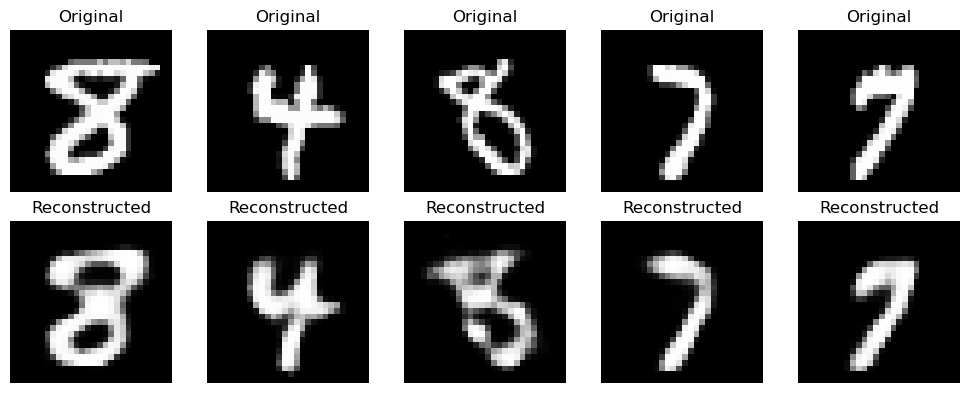

In [ ]:
plt.figure(figsize=(10, 4))
for i in range(5):
    
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    
    plt.subplot(2, 5, i + 6)
    plt.imshow(reconstructed_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [14]:
encoded_train = encoder.predict(X_train)
encoded_test = encoder.predict(X_test)

1750/1750 ━━━━━━━━━━━━━━━━━━━━ 1s 711us/step
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 839us/step


In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_test_2d = pca.fit_transform(encoded_test)

The visualization shows that the encoded features are not clearly separated by class because the autoencoder is trained in an unsupervised way and focuses on reconstruction rather than classification.

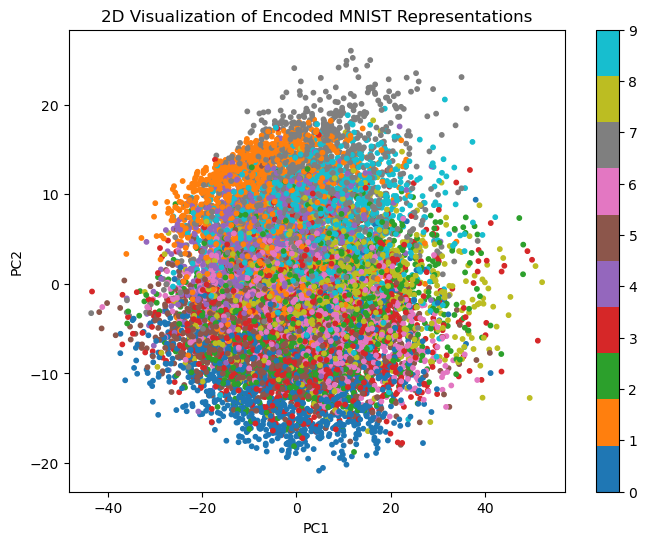

In [16]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test.astype(int), cmap='tab10', s=10)
plt.colorbar(scatter)
plt.title("2D Visualization of Encoded MNIST Representations")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [17]:
query_index = 0
query_img = X_test[query_index].reshape(1, -1)
query_label = y_test[query_index]

In [18]:
query_encoded = encoder.predict(query_img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


In [19]:
similarities = cosine_similarity(query_encoded, encoded_train)[0]

In [20]:
top_k = 5
top_k_indices = np.argsort(similarities)[-top_k:][::-1]

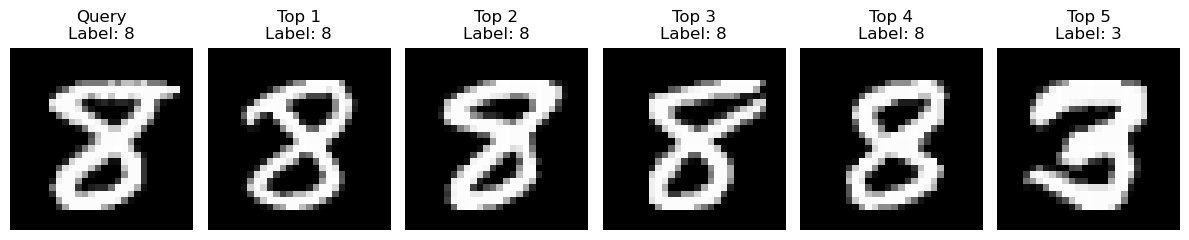

In [ ]:
plt.figure(figsize=(12, 3))

plt.subplot(1, top_k + 1, 1)
plt.imshow(query_img.reshape(28, 28), cmap='gray')
plt.title(f"Query\nLabel: {query_label}")
plt.axis('off')

for i, idx in enumerate(top_k_indices):
    plt.subplot(1, top_k + 1, i + 2)
    plt.imshow(X_train[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Top {i+1}\nLabel: {y_train[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Insights

- The autoencoder successfully learned to reconstruct MNIST images.
- Training and validation loss decreased without overfitting.
- Latent space does not clearly separate classes (unsupervised learning).
- Cosine similarity retrieves visually similar images effectively.

## Results Summary

- Reconstruction quality: Good
- Loss: Decreasing and stable
- Latent space: Not clearly clustered
- Retrieval: High similarity results

## Conclusion

- Autoencoder is useful for reconstruction and feature extraction.
- It performs well in image retrieval tasks.
- It is not suitable for classification without labels.